In [4]:
import kagglehub
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bitcoin-historical-data' dataset.
Path to dataset files: /kaggle/input/bitcoin-historical-data


**IMPORTING THE FILES**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**READ THE CSV**

In [6]:
df = pd.read_csv('btcusd_1-min_data.csv')
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


EDA

In [9]:
df.describe()

,Timestamp,Open,High,Low,Close,Volume
count,8.835500e+04,88354.000000,88354.00000,88354.000000,88354.000000,88354.000000
mean,1.328063e+09,5.734330,5.73436,5.734282,5.734320,0.083149
std,1.530362e+06,0.828596,0.82861,0.828596,0.828612,1.365356
min,1.325412e+09,3.800000,3.80000,3.800000,3.800000,0.000000
25%,1.326737e+09,5.000000,5.00000,5.000000,5.000000,0.000000
50%,1.328063e+09,5.780000,5.78000,5.780000,5.780000,0.000000
75%,1.329388e+09,6.400000,6.40000,6.400000,6.400000,0.000000
max,1.330713e+09,7.380000,7.38000,7.380000,7.380000,92.654874


In [12]:
df.isnull().sum()

,0
Timestamp,0
Open,1
High,1
Low,1
Close,1
Volume,1


REVOME NULL VALUES

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Timestamp,0
Open,0
High,0
Low,0
Close,0
Volume,0


INITIALIZING FEARTURES

In [20]:
df['target'] = (df['Close'].shift(-60) > df['Close']).astype(int)
df['target'].value_counts()

,count
target,
0,77988
1,10366


In [53]:
df['avg_50'] = df['Close'].rolling(50).mean()

df['momentum'] = df['Close'] - df['Close'].shift(5)

df['avg_10'] = df['Close'].rolling(10).mean()

df['avg_30'] = df['Close'].rolling(30).mean()


**DEFINE X AND y**

In [55]:
y = df['target']
X = df.drop(['target', 'Timestamp', 'diff_closing', 'diff_hig_low'], axis=1)

print(X.columns.tolist())
print(X.shape)

['Open', 'High', 'Low', 'Close', 'Volume', 'avg_10', 'avg_30', 'avg_50', 'momentum']
(88354, 9)


In [56]:
from sklearn.model_selection import train_test_split

train_X, test_X , train_y , test_y = train_test_split(X, y , random_state=42 , test_size=0.2)

print(train_X.shape)
print(test_y.shape)

(70683, 9)
(17671,)


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

my_mod = RandomForestClassifier(n_estimators=100,max_depth=15,  min_samples_split=5, class_weight='balanced', random_state=42)
my_mod.fit(train_X, train_y)

predictions = my_mod.predict(test_X)
accuracy = accuracy_score(test_y , predictions)

print(f'Accuracy : {accuracy}')

Accuracy : 0.7699620847716597


In [62]:
from xgboost import XGBClassifier

xgb_mod = XGBClassifier(n_estimators=200, scale_pos_weight=7, random_state=42)
xgb_mod.fit(train_X, train_y)

predictions = xgb_mod.predict(test_X)
accuracy = accuracy_score(test_y , predictions)

print(f'Accuracy : {accuracy}')

Accuracy : 0.7869956425782355


In [63]:
train_predictions = my_mod.predict(train_X)
print(f"Training: {accuracy_score(train_y, train_predictions)}")

Training: 0.7668180467722083


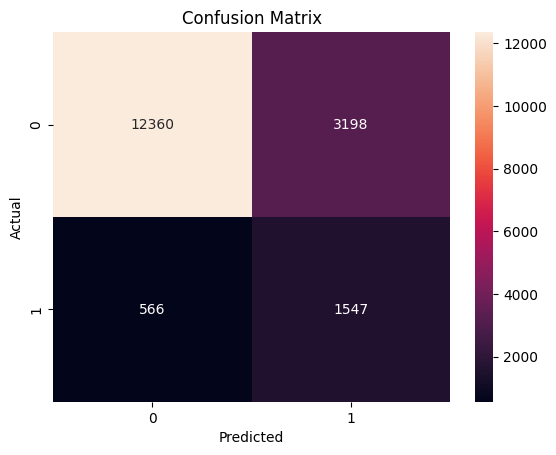

In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_y, predictions)
sns.heatmap(cm, annot=True , fmt ='d')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

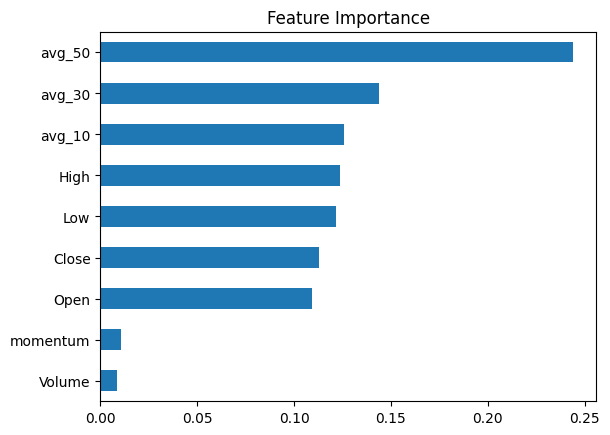

In [61]:
feat_imp = pd.Series(
    my_mod.feature_importances_,
    index = X.columns
)

feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

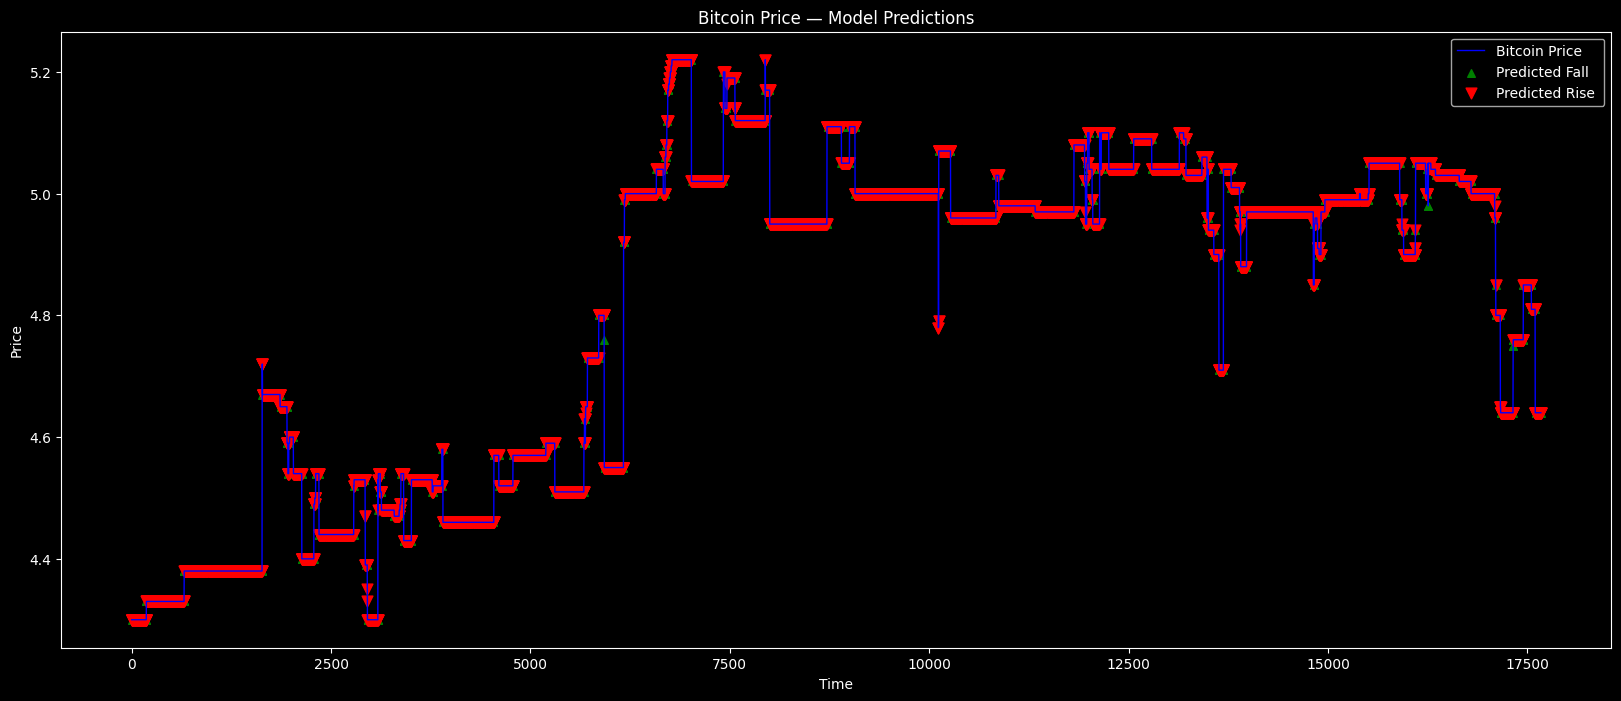

In [76]:
actual_price = df['Close'].iloc[-len(test_y):]
predictions_series = pd.Series(predictions,
                     index=actual_price.index)

plt.figure(figsize=(20,8))


plt.plot(actual_price.values, color='blue',
         label='Bitcoin Price', linewidth=1)

plt.scatter(
    predictions_series[predictions_series==1].index - actual_price.index[0],
    actual_price[predictions_series==1].values,
    color='green', label='Predicted Fall ',
    marker='^', s=30 )

plt.scatter(
    predictions_series[predictions_series==0].index - actual_price.index[0],
    actual_price[predictions_series==0].values,
    color='red', label='Predicted Rise ',
    marker='v', s=60)

plt.title('Bitcoin Price — Model Predictions')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()
plt.show()

In [73]:
import numpy as np
print("0 predictions:", np.sum(predictions==0))
print("1 predictions:", np.sum(predictions==1))

0 predictions: 12445
1 predictions: 5226
